# Phase 2: Data Preprocessing

## Objectives

In this phase, you will:

1. Load the cleaned dataset from Phase 1
2. Encode categorical variables for model compatibility
3. Analyze and handle skewness in numerical features
4. Apply appropriate scaling techniques
5. Prepare separate train and test datasets
6. Create a fully preprocessed dataset ready for feature engineering

## Instructions

Complete each task in order. This notebook builds on the cleaned data from Phase 1.

---
## Task 1: Import Libraries and Load Cleaned Data

In [782]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")



Libraries imported successfully!


In [783]:

df = pd.read_csv('train_cleaned.csv')


print(df.shape)
print(df.info())
print(df.head(5))

(1429, 69)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1429 entries, 0 to 1428
Data columns (total 69 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1429 non-null   int64  
 1   MSZoning       1429 non-null   object 
 2   LotFrontage    1429 non-null   float64
 3   LotArea        1429 non-null   int64  
 4   LotShape       1429 non-null   object 
 5   LandContour    1429 non-null   object 
 6   LotConfig      1429 non-null   object 
 7   LandSlope      1429 non-null   object 
 8   Neighborhood   1429 non-null   object 
 9   Condition1     1429 non-null   object 
 10  BldgType       1429 non-null   object 
 11  HouseStyle     1429 non-null   object 
 12  OverallQual    1429 non-null   int64  
 13  OverallCond    1429 non-null   int64  
 14  YearBuilt      1429 non-null   int64  
 15  YearRemodAdd   1429 non-null   int64  
 16  RoofStyle      1429 non-null   object 
 17  Exterior1st    1429 non-null   object 
 1

---
## Task 2: Separate Features and Target

Separate the target variable (SalePrice) from the features for preprocessing.

In [784]:
# TODO: Separate target variable from features
# - Create 'y' = copy of 'SalePrice' column
# - Create 'X' = dataframe without 'SalePrice'
Y = df['SalePrice'].copy()
X = df.drop(columns=['SalePrice'])


# TODO: Drop 'Id' column from X if it exists (not useful for modeling)
# - Check if 'Id' in X.columns
# - If yes, drop it
if 'Id' in df.columns:
    print("Id column exists in the dataset.")
else:
    print("Id column is already dropped.")

# TODO: Print information
print(X.shape)
print(Y.shape)
print(Y.describe())


Id column is already dropped.
(1429, 68)
(1429,)


count      1429.000000
mean     176780.205738
std       70626.306123
min       34900.000000
25%      129500.000000
50%      161000.000000
75%      210000.000000
max      485000.000000
Name: SalePrice, dtype: float64


---
## Task 3: Identify Feature Types for Encoding

Categorize features and determine appropriate encoding strategies.

In [785]:

categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(exclude='object').columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

numeric_but_categorical = [
    'MSSubClass',
    'OverallQual',
    'OverallCond',
    'MoSold',
    'YrSold'
]
true_numerical = [
    col for col in df.select_dtypes(exclude='object').columns
    if col not in numeric_but_categorical
]
categorical_cols_final = (
    df.select_dtypes(include='object').columns.tolist()
    + numeric_but_categorical
)
print("Final Categorical Columns:")
print(categorical_cols_final)

print("\nFinal Numerical Columns:")
print(true_numerical)


Categorical columns:
['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']

Numerical columns:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice'

In [786]:
# TODO: Analyze categorical features cardinality
for i in categorical_cols_final:
    print(f"{i} - {df[i].nunique()}")


MSZoning - 5
LotShape - 4
LandContour - 4
LotConfig - 5
LandSlope - 3
Neighborhood - 25
Condition1 - 9
BldgType - 5
HouseStyle - 8
RoofStyle - 6
Exterior1st - 15
Exterior2nd - 16
ExterQual - 4
ExterCond - 5
Foundation - 6
BsmtQual - 4
BsmtCond - 4
BsmtExposure - 4
BsmtFinType1 - 6
BsmtFinType2 - 6
HeatingQC - 5
CentralAir - 2
Electrical - 5
KitchenQual - 4
Functional - 7
FireplaceQu - 5
GarageType - 6
GarageFinish - 3
GarageQual - 5
GarageCond - 5
PavedDrive - 3
SaleType - 9
SaleCondition - 6
MSSubClass - 15
OverallQual - 10
OverallCond - 9
MoSold - 12
YrSold - 5


In [787]:
X[ordinal_features].isna().sum()

ExterQual         0
ExterCond         0
BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     37
HeatingQC         0
KitchenQual       0
Functional        0
FireplaceQu     689
GarageFinish     81
GarageQual       81
GarageCond       81
LandSlope         0
LotShape          0
PavedDrive        0
OverallQual       0
OverallCond       0
dtype: int64

---
## Task 4: Encode Categorical Variables

### Encoding Strategy:

1. **Ordinal Features** (with natural order): Use Label Encoding or manual mapping
   - Examples: Quality ratings (Ex, Gd, TA, Fa, Po), Condition ratings
   
2. **Nominal Features** (no natural order): Use One-Hot Encoding
   - Examples: Neighborhood, Building Type, Exterior Type
   
3. **High Cardinality Features** (>10 unique values): Consider frequency encoding or target encoding (advanced)

Refer to `data_description.txt` to identify ordinal features.

### Step 4.1: Identify Ordinal vs Nominal Features

Review the data description and categorize your features.

In [788]:
ordinal_features = [
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'HeatingQC',
    'KitchenQual',
    'Functional',
    'FireplaceQu',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'LandSlope',
    'LotShape',
    'PavedDrive',
    'OverallQual',
    'OverallCond'
]
nominal_features = [
    col for col in categorical_cols_final
    if col not in ordinal_features
]
ordinal_mappings = {
    'ExterQual':   {'Po':1, 'Fa':2, 'TA':3, 'Gd':4, 'Ex':5},
    'ExterCond':   {'Po':1, 'Fa':2, 'TA':3, 'Gd':4, 'Ex':5},
    'BsmtQual':    {'None':0, 'Po':1, 'Fa':2, 'TA':3, 'Gd':4, 'Ex':5},
    'BsmtCond':    {'None':0, 'Po':1, 'Fa':2, 'TA':3, 'Gd':4, 'Ex':5},
    'HeatingQC':   {'Po':1, 'Fa':2, 'TA':3, 'Gd':4, 'Ex':5},
    'KitchenQual': {'Po':1, 'Fa':2, 'TA':3, 'Gd':4, 'Ex':5},
    'FireplaceQu': {'None':0, 'Po':1, 'Fa':2, 'TA':3, 'Gd':4, 'Ex':5},
    'GarageQual':  {'None':0, 'Po':1, 'Fa':2, 'TA':3, 'Gd':4, 'Ex':5},
    'GarageCond':  {'None':0, 'Po':1, 'Fa':2, 'TA':3, 'Gd':4, 'Ex':5},
    'GarageFinish': {'None':0, 'Unf':1, 'RFn':2, 'Fin':3},
    'BsmtExposure': {'None':0, 'No':1, 'Mn':2, 'Av':3, 'Gd':4},
    'BsmtFinType1': {'None':0, 'Unf':1, 'LwQ':2, 'Rec':3, 'BLQ':4, 'ALQ':5, 'GLQ':6},
    'BsmtFinType2': {'None':0, 'Unf':1, 'LwQ':2, 'Rec':3, 'BLQ':4, 'ALQ':5, 'GLQ':6},
    'Functional':   {'Sal':1, 'Sev':2, 'Maj2':3, 'Maj1':4, 'Mod':5, 'Min2':6, 'Min1':7, 'Typ':8},
    'LandSlope':    {'Sev':1, 'Mod':2, 'Gtl':3},
    'LotShape':     {'IR3':1, 'IR2':2, 'IR1':3, 'Reg':4},
    'PavedDrive':   {'N':1, 'P':2, 'Y':3}
}
print(f"Ordinal features ({len(ordinal_features)}):")
print(ordinal_features, "\n")

print(f"Nominal features ({len(nominal_features)}):")
print(nominal_features)

Ordinal features (19):
['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 'LandSlope', 'LotShape', 'PavedDrive', 'OverallQual', 'OverallCond'] 

Nominal features (19):
['MSZoning', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'Foundation', 'CentralAir', 'Electrical', 'GarageType', 'SaleType', 'SaleCondition', 'MSSubClass', 'MoSold', 'YrSold']


### Step 4.2: Apply Ordinal Encoding

In [789]:
# Create a copy for encoding
X_encoded = X.copy()

# Apply ordinal encoding
for col, mapping in ordinal_mappings.items():
    if col in X_encoded.columns:
        X_encoded[col] = X_encoded[col].fillna('None').map(mapping)
        print(f"Encoded ordinal feature: {col}")

# Verify encoding
X_encoded[ordinal_features].head(5)


Encoded ordinal feature: ExterQual
Encoded ordinal feature: ExterCond
Encoded ordinal feature: BsmtQual
Encoded ordinal feature: BsmtCond
Encoded ordinal feature: HeatingQC
Encoded ordinal feature: KitchenQual
Encoded ordinal feature: FireplaceQu
Encoded ordinal feature: GarageQual
Encoded ordinal feature: GarageCond
Encoded ordinal feature: GarageFinish
Encoded ordinal feature: BsmtExposure
Encoded ordinal feature: BsmtFinType1
Encoded ordinal feature: BsmtFinType2
Encoded ordinal feature: Functional
Encoded ordinal feature: LandSlope
Encoded ordinal feature: LotShape
Encoded ordinal feature: PavedDrive


,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,HeatingQC,KitchenQual,Functional,FireplaceQu,GarageFinish,GarageQual,GarageCond,LandSlope,LotShape,PavedDrive,OverallQual,OverallCond
0,4,3,4,3,1,6,1,5,4,8,0,2,3,3,3,4,3,7,5
1,3,3,4,3,4,5,1,5,3,8,3,2,3,3,3,4,3,6,8
2,4,3,4,3,2,6,1,5,4,8,3,2,3,3,3,3,3,7,5
3,3,3,3,4,1,5,1,4,4,8,4,1,3,3,3,3,3,7,5
4,4,3,4,3,3,6,1,5,4,8,3,2,3,3,3,3,3,8,5


### Step 4.3: Apply One-Hot Encoding to Nominal Features

In [790]:
# TODO: Apply one-hot encoding to nominal features
# - Check if nominal_features list is not empty
# - Use pd.get_dummies() with:
#   * columns=nominal_features
#   * drop_first=True (to avoid multicollinearity)
# - Print new shape and feature count
# Apply one-hot encoding to nominal features
# Apply one-hot encoding to nominal features
# Keep only nominal features that are still in X_encoded
nominal_features_existing = [
    col for col in nominal_features if col in X_encoded.columns
]

if nominal_features_existing:
    X_encoded = pd.get_dummies(
        X_encoded,
        columns=nominal_features_existing,
        drop_first=True
    )

print("Shape after one-hot encoding:", X_encoded.shape)
print("Total number of features:", X_encoded.shape[1])


Shape after one-hot encoding: (1429, 194)
Total number of features: 194


In [791]:
# TODO: Display sample of encoded dataset
# - Print message
# - Show first few rows of X_encoded
# Display sample of encoded dataset
# Display sample of encoded dataset
print("Sample of encoded dataset:")
X_encoded.head()


Sample of encoded dataset:


,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_120,MSSubClass_160,MSSubClass_180,MSSubClass_190,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9,MoSold_10,MoSold_11,MoSold_12,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010
0,65.0,8450,4,3,7,5,2003,2003,196.0,4,3,4,3,1,6,706,1,0,150,856,5,856,854,1710,1,0,2,1,3,1,4,8,8,0,0,2003.0,2,2,548,3,3,3,0,61,0,0,0,0,0,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,80.0,9600,4,3,6,8,1976,1

In [792]:
numerical_df = df[true_numerical]
numerical_df.head()


,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,SalePrice
0,65.0,8450,2003,2003,196.0,706,0,150,856,856,854,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,208500
1,80.0,9600,1976,1976,0.0,978,0,284,1262,1262,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,181500
2,68.0,11250,2001,2002,162.0,486,0,434,920,920,866,1786,1,0,2,1,3,1,6,1,2001.0,2,608,0,42,0,0,0,0,0,223500
3,60.0,9550,1915,1970,0.0,216,0,540,756,961,756,1717,1,0,1,0,3,1,7,1,1998.0,3,642,0,35,272,0,0,0,0,140000
4,84.0,14260,2000,2000,350.0,655,0,490,1145,1145,1053,2198,1,0,2,1,4,1,9,1,2000.0,3,836,192,84,0,0,0,0,0,250000


In [793]:
import pandas as pd
import numpy as np

print(" Shape (rows, columns):")
print(X_encoded.shape)

print("\n Data types count:")
print(X_encoded.dtypes.value_counts())

print("\n First 5 rows:")
display(X_encoded.head())

print("\n Missing values (if any):")
missing = X_encoded.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
display(missing if not missing.empty else "No missing values")

print("\n Basic statistics (numeric features):")
display(X_encoded.describe())

print("\n Any infinite values?")
print(np.isinf(X_encoded.select_dtypes(include=[np.number])).sum().sum())

print("\n Memory usage (MB):")
print(round(X_encoded.memory_usage(deep=True).sum() / 1024**2, 2))


 Shape (rows, columns):
(1429, 194)

 Data types count:
bool       145
int64       46
float64      3
Name: count, dtype: int64

 First 5 rows:


,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_120,MSSubClass_160,MSSubClass_180,MSSubClass_190,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9,MoSold_10,MoSold_11,MoSold_12,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010
0,65.0,8450,4,3,7,5,2003,2003,196.0,4,3,4,3,1,6,706,1,0,150,856,5,856,854,1710,1,0,2,1,3,1,4,8,8,0,0,2003.0,2,2,548,3,3,3,0,61,0,0,0,0,0,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,80.0,9600,4,3,6,8,1976,1


 Missing values (if any):


'No missing values'


 Basic statistics (numeric features):


,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal
count,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000
mean,69.429671,9667.170749,3.608118,2.948915,6.064381,5.580826,1971.034290,1984.713086,98.182645,3.383485,3.083975,3.473758,2.932820,1.597621,3.517845,425.020294,1.240028,44.786564,565.004199,1034.811057,4.142057,1142.644507,343.793562,1492.409377,0.414276,0.056683,1.552834,0.380686,2.862841,1.046886,3.498950,6.473758,7.846746,0.592722,1.788663,1978.487754,1.701889,1.751575,467.812456,2.806858,2.804759,2.855843,91.421274,45.545836,21.930021,3.483555,14.680896,2.094472,43.592722
std,20.860820,4013.153497,0.566666,0.241481,1.350920,1.115813,30.284567,20.694225,170.502777,0.562514,0.352982,0.872978,0.557324,1.040373,2.109535,418.609498,0.879533,157.932701,438.570541,390.445432,0.959313,350.485539,429.324117,483.947318,0.512278,0.237294,0.539258,0.502728,0.808358,0.221180,0.655321,1.581641,0.657555,0.630106,1.808433,24.011975,0.889955,0.744169,210.288297,0.729862,0.726898,0.496700,120.843037,65.072962,60.974595,29.629492,55.188729,35.715577,500.994215
min,21.000000,1300.000000,1.000000,1.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,334.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,2.000000,0.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60.000000,7500.000000,3.000000,3.000000,5.000000,5.000000,1953.000000,1966.000000,0.000000,3.000000,3.000000,3.000000,3.000000,1.000000,1.000000,0.000000,1.000000,0.000000,223.000000,793.000000,3.000000,876.000000,0.000000,1125.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,3.000000,5.000000,8.000000,0.000000,0.000000,1962.000000,1.000000,1.000000,322.000000,3.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,69.000000,9375.000000,4.000000,3.000000,6.000000,5.000000,1972.000000,1993.000000,0.000000,3.000000,3.000000,3.000000,3.000000,1.000000,4.000000,375.000000,1.000000,0.000000,476.000000,981.000000,5.000000,1078.000000,0.000000,1453.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,3.000000,6.000000,8.000000,1.000000,2.000000,1980.000000,2.000000,2.000000,475.000000,3.000000,3.000000,3.000000,0.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,79.000000,11414.000000,4.000000,3.000000,7.000000,6.000000,2000.000000,2004.000000,160.000000,4.000000,3.000000,4.000000,3.000000,2.000000,6.000000,696.000000,1.000000,0.000000,804.000000,1268.000000,5.000000,1368.000000,728.000000,1762.000000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,4.000000,7.000000,8.000000,1.000000,4.000000,2001.000000,2.000000,2.000000,576.000000,3.000000,3.000000,3.000000,168.000000,66.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,313.000000,34


 Any infinite values?
0

 Memory usage (MB):
0.73


---
## Task 5: Analyze Distribution and Skewness

Examine the distribution of numerical features and identify highly skewed features.

In [794]:

# TODO: Calculate skewness for all numerical features
# - Select numerical columns using select_dtypes
num_features = X_encoded.select_dtypes(include=[np.number])
# - Apply stats.skew() to each column
skewness = num_features.apply(lambda x: stats.skew(x))
# - Create DataFrame with Feature and Skewness columns
skewness_df = pd.DataFrame({
    "Feature": skewness.index,
    "Skewness": skewness.values
})

skewness_df = skewness_df.reindex(
    skewness_df["Skewness"].abs().sort_values(ascending=False).index
)
print(skewness_df)

print("Top 20 most skewed features:")
highly_skewed = skewness_df[
    skewness_df["Skewness"].abs() > 0.75
]["Feature"].tolist()
print(f"\nNumber of highly skewed features (|skew| > 0.75): {len(highly_skewed)}")
print(highly_skewed)





          Feature   Skewness
48        MiscVal  24.258264
47       PoolArea  17.339895
45      3SsnPorch  10.180911
3       LandSlope  -5.076694
32     Functional  -5.016499
29   KitchenAbvGr   4.468915
17     BsmtFinSF2   4.345208
46    ScreenPorch   4.209822
25   BsmtHalfBath   4.145275
12       BsmtCond  -3.667015
16   BsmtFinType2   3.337728
41     PavedDrive  -3.300545
40     GarageCond  -3.283803
39     GarageQual  -3.187242
44  EnclosedPorch   3.089728
8      MasVnrArea   2.619659
43    OpenPorchSF   2.383142
0     LotFrontage   1.715707
42     WoodDeckSF   1.437519
10      ExterCond   1.375095
11       BsmtQual  -1.322180
2        LotShape  -1.297054
1         LotArea   1.224225
13   BsmtExposure   1.152051
18      BsmtUnfSF   0.914869
9       ExterQual   0.809095
23      GrLivArea   0.790892
22       2ndFlrSF   0.753987
15     BsmtFinSF1   0.709327
27       HalfBath   0.689105
5     OverallCond   0.687811
35    GarageYrBlt  -0.670010
21       1stFlrSF   0.655950
33     Firepla

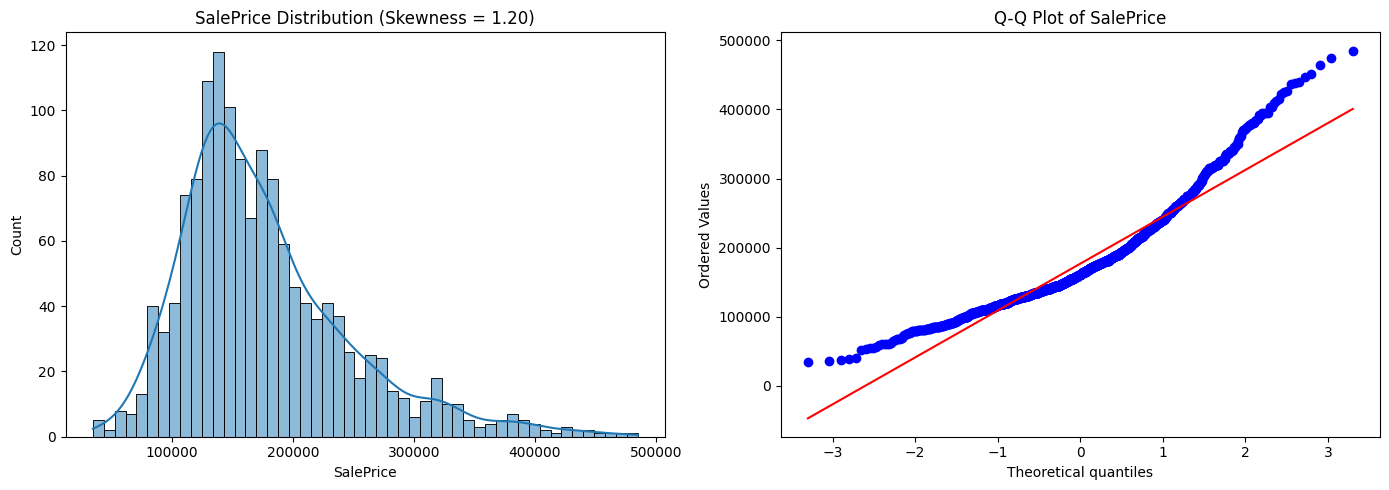

Target variable (SalePrice) skewness: 1.2042


In [795]:
# TODO: Visualize distribution of target variable
# - Create 1x2 subplot figure (figsize=(14, 5))
# - Left plot: Histogram of SalePrice with skewness in title
# - Right plot: Q-Q plot using stats.probplot()
# - Display the plots

from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate skewness of target variable
target_skewness = stats.skew(Y)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.histplot(Y, bins=50, kde=True, ax=axes[0])
axes[0].set_title(f"SalePrice Distribution (Skewness = {target_skewness:.2f})")
axes[0].set_xlabel("SalePrice")


stats.probplot(Y, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of SalePrice")

plt.tight_layout()
plt.show()


print(f"Target variable (SalePrice) skewness: {target_skewness:.4f}")




---
## Task 6: Handle Skewness

Apply transformations to reduce skewness in highly skewed features.

**Common transformations:**
- Log transformation: `log1p(x)` - good for right-skewed data
- Square root: `sqrt(x)` - moderate right skewness
- Box-Cox: Automatic optimal transformation (requires positive values)

**When to apply:**
- Right-skewed (positive skewness > 0.75): Use log transformation
- Left-skewed (negative skewness < -0.75): Consider reflection + log

### Step 6.1: Transform Target Variable

If the target variable is skewed, transform it for better model performance.

Original SalePrice skewness: 1.2042
Transformed (log1p) SalePrice skewness: -0.0471


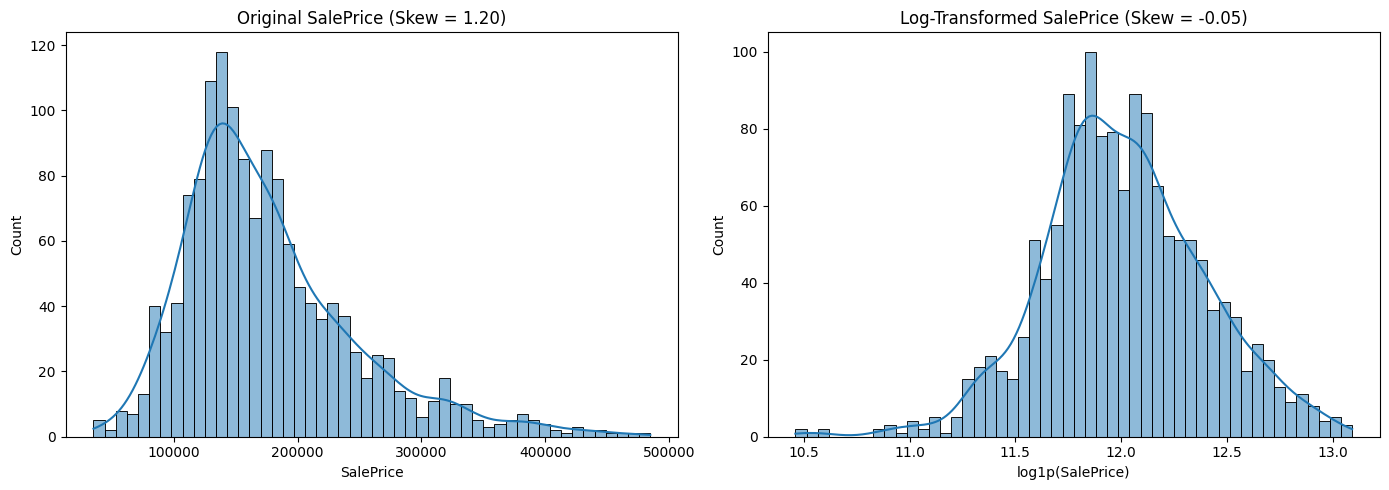

In [796]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


original_skew = stats.skew(Y)

print(f"Original SalePrice skewness: {original_skew:.4f}")

# Check if transformation is needed
if abs(original_skew) > 0.75:
    # Apply log transformation
    Y_log = np.log1p(Y)

    # Calculate new skewness
    transformed_skew = stats.skew(Y_log)

    print(f"Transformed (log1p) SalePrice skewness: {transformed_skew:.4f}")

    # Create side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(Y, bins=50, kde=True, ax=axes[0])
    axes[0].set_title(f"Original SalePrice (Skew = {original_skew:.2f})")
    axes[0].set_xlabel("SalePrice")

    sns.histplot(Y_log, bins=50, kde=True, ax=axes[1])
    axes[1].set_title(f"Log-Transformed SalePrice (Skew = {transformed_skew:.2f})")
    axes[1].set_xlabel("log1p(SalePrice)")

    plt.tight_layout()
    plt.show()
else:
    Y_log = Y.copy()
    print("Target variable is not highly skewed. No transformation applied.")






### Step 6.2: Transform Highly Skewed Features

In [797]:

X_transformed = X_encoded.copy()

# Apply log transformation to highly skewed features
for feature in highly_skewed:
    if feature in X_transformed.columns:
        # Check if all values are non-negative
        if (X_transformed[feature] >= 0).all():
            before_skew = stats.skew(X_transformed[feature])
            
            # Apply log1p transformation
            X_transformed[feature] = np.log1p(X_transformed[feature])
            
            after_skew = stats.skew(X_transformed[feature])
            
            print(
                f"{feature}: "
                f"skewness before = {before_skew:.4f}, "
                f"after = {after_skew:.4f}"
            )
        else:
            print(f"{feature}: contains negative values, skipped.")

print("\nLog transformation applied to eligible highly skewed features.")

MiscVal: skewness before = 24.2583, after = 5.2215
PoolArea: skewness before = 17.3399, after = 16.8288
3SsnPorch: skewness before = 10.1809, after = 7.6404
LandSlope: skewness before = -5.0767, after = -5.7205
Functional: skewness before = -5.0165, after = -5.8190
KitchenAbvGr: skewness before = 4.4689, after = 3.8443
BsmtFinSF2: skewness before = 4.3452, after = 2.5729
ScreenPorch: skewness before = 4.2098, after = 3.1945
BsmtHalfBath: skewness before = 4.1453, after = 3.9686
BsmtCond: skewness before = -3.6670, after = -5.0903
BsmtFinType2: skewness before = 3.3377, after = 1.8752
PavedDrive: skewness before = -3.3005, after = -3.3823
GarageCond: skewness before = -3.2838, after = -3.5976
GarageQual: skewness before = -3.1872, after = -3.5949
EnclosedPorch: skewness before = 3.0897, after = 2.1063
MasVnrArea: skewness before = 2.6197, after = 0.5135
OpenPorchSF: skewness before = 2.3831, after = -0.0026
LotFrontage: skewness before = 1.7157, after = -0.9994
WoodDeckSF: skewness befo

---
## Task 7: Feature Scaling

Apply appropriate scaling to numerical features.

**Scaling methods:**
1. **StandardScaler**: Mean=0, StdDev=1 (good for normally distributed data)
2. **MinMaxScaler**: Scale to [0,1] range (good for bounded distributions)
3. **RobustScaler**: Uses median and IQR (robust to outliers)

**When to use:**
- StandardScaler: Most common, works well after skewness correction
- RobustScaler: When outliers are present and important
- MinMaxScaler: When feature range matters (e.g., neural networks)

In [798]:
# Select numerical columns after transformation
numeric_features = X_transformed.select_dtypes(include=[np.number]).columns.tolist()

# Print count of numerical features to scale
print(f"Number of numerical features to scale: {len(numeric_features)}")

Number of numerical features to scale: 49


### Step 7.1: Choose and Apply Scaling Method

Select a scaling method and apply it to numerical features.

In [799]:
from sklearn.preprocessing import StandardScaler

# Create a copy for scaling
X_scaled = X_transformed.copy()

# Choose and initialize scaling method
scaler = StandardScaler()

# Apply scaling to numerical features
X_scaled[numeric_features] = scaler.fit_transform(X_scaled[numeric_features])

# Print scaler info and basic statistics
print("Scaling method applied: StandardScaler")
print("Scaled feature statistics (mean, std):")
print(X_scaled[numeric_features].describe().loc[['mean', 'std']])


Scaling method applied: StandardScaler
Scaled feature statistics (mean, std):
       LotFrontage       LotArea      LotShape     LandSlope   OverallQual  \
mean -8.701538e-17 -8.670461e-16  1.138037e-15 -2.392923e-16 -2.933661e-16   
std   1.000350e+00  1.000350e+00  1.000350e+00  1.000350e+00  1.000350e+00   

       OverallCond     YearBuilt  YearRemodAdd    MasVnrArea     ExterQual  \
mean  2.709908e-16 -2.535877e-16  3.152443e-15  1.392246e-16  1.060966e-15   
std   1.000350e+00  1.000350e+00  1.000350e+00  1.000350e+00  1.000350e+00   

         ExterCond      BsmtQual      BsmtCond  BsmtExposure  BsmtFinType1  \
mean -1.939200e-15 -3.132554e-16 -6.277538e-16  1.037969e-16 -3.604923e-17   
std   1.000350e+00  1.000350e+00  1.000350e+00  1.000350e+00  1.000350e+00   

        BsmtFinSF1  BsmtFinType2    BsmtFinSF2     BsmtUnfSF   TotalBsmtSF  \
mean -2.237538e-17 -4.127015e-16  4.972307e-17 -5.718154e-17  1.193354e-16   
std   1.000350e+00  1.000350e+00  1.000350e+00  1.000350e+00 

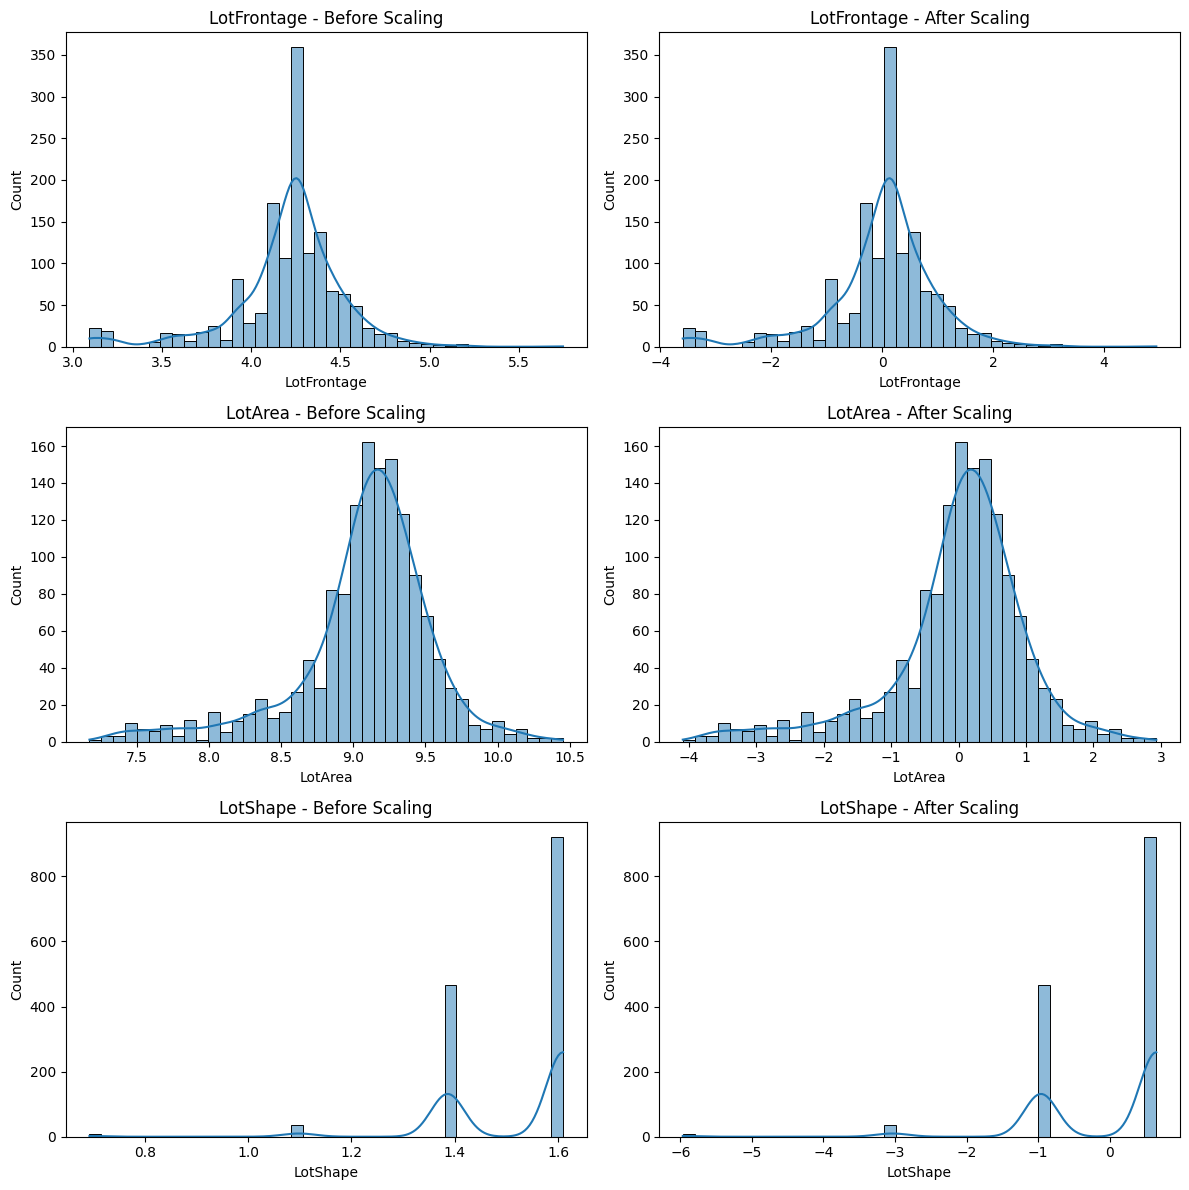

In [800]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select first 3 numerical features for visualization
sample_features = numeric_features[:3]

# Create subplots
fig, axes = plt.subplots(len(sample_features), 2, figsize=(12, 4 * len(sample_features)))

# Handle case when only one feature
if len(sample_features) == 1:
    axes = [axes]

# Plot before vs after scaling
for i, feature in enumerate(sample_features):
    # Before scaling
    sns.histplot(X_transformed[feature], bins=40, kde=True, ax=axes[i][0])
    axes[i][0].set_title(f"{feature} - Before Scaling")

    # After scaling
    sns.histplot(X_scaled[feature], bins=40, kde=True, ax=axes[i][1])
    axes[i][1].set_title(f"{feature} - After Scaling")

plt.tight_layout()
plt.show()


---
## Task 8: Process Test Dataset

Apply the same preprocessing steps to the test dataset.

**Important:** Use the same transformations and scaling parameters from the training set.

In [801]:

test_df = pd.read_csv("test.csv")


print("Test dataset shape:", test_df.shape)
print("\nMissing values in test dataset:")
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])


test_ids = test_df["Id"].copy()


test_df = test_df.drop(columns=["Id"])

print("\nId column saved and dropped from test dataset.")

Test dataset shape: (1459, 80)

Missing values in test dataset:
MSZoning           4
LotFrontage      227
Alley           1352
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType       894
MasVnrArea        15
BsmtQual          44
BsmtCond          45
BsmtExposure      44
BsmtFinType1      42
BsmtFinSF1         1
BsmtFinType2      42
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
FireplaceQu      730
GarageType        76
GarageYrBlt       78
GarageFinish      78
GarageCars         1
GarageArea         1
GarageQual        78
GarageCond        78
PoolQC          1456
Fence           1169
MiscFeature     1408
SaleType           1
dtype: int64

Id column saved and dropped from test dataset.


### Step 8.1: Apply Same Cleaning and Encoding to Test Data

Replicate your Phase 1 cleaning steps and encoding from this notebook.

**Key considerations:**
- Handle missing values using same strategy
- Apply same feature drops
- Use same encoding mappings

In [802]:

test_encoded = test_df.copy()


for col, mapping in ordinal_mappings.items():
    if col in test_encoded.columns:
        test_encoded[col] = test_encoded[col].fillna('None').map(mapping)


test_encoded = pd.get_dummies(
    test_encoded,
    columns=nominal_features_existing,
    drop_first=True
)


missing_cols = set(X_encoded.columns) - set(test_encoded.columns)
for col in missing_cols:
    test_encoded[col] = 0


test_encoded = test_encoded[X_encoded.columns]

print("Test encoding completed.")
print("Shape after encoding:", test_encoded.shape)


# =========================
# Apply log transformations (same skewed features)
# =========================

test_transformed = test_encoded.copy()

for feature in highly_skewed:
    if feature in test_transformed.columns:
        if (test_transformed[feature] >= 0).all():
            test_transformed[feature] = np.log1p(test_transformed[feature])


test_scaled = test_transformed.copy()
test_scaled[numeric_features] = scaler.transform(test_scaled[numeric_features])

print("Test preprocessing fully completed.")
print("Final test shape:", test_scaled.shape)
print("Any missing values:", test_scaled.isnull().any().any())



Test encoding completed.
Shape after encoding: (1459, 194)
Test preprocessing fully completed.
Final test shape: (1459, 194)
Any missing values: True


---
## Task 9: Final Verification and Save

Verify preprocessing is complete and save the datasets.

In [ ]:

print("TRAINING SET VERIFICATION")
print("-" * 40)

print("Shape:", X_scaled.shape)

print("\nMissing values (total):")
print(X_scaled.isnull().sum().sum())

print("\nData types distribution:")
print(X_scaled.dtypes.value_counts())


print("\nTARGET VARIABLE VERIFICATION")
print("-" * 40)

print("Shape:", Y_log.shape if 'Y_log' in globals() else Y.shape)

target_used = Y_log if 'Y_log' in globals() else Y

print("Min value:", target_used.min())
print("Max value:", target_used.max())
print("Skewness:", stats.skew(target_used))


print("\nFINAL FEATURE TYPE CHECK")
print("-" * 40)

object_cols = X_scaled.select_dtypes(include='object').columns.tolist()

if len(object_cols) == 0:
    print("All features are numeric. ")
else:
    print("Non-numeric features found:")
    print(object_cols)


TRAINING SET VERIFICATION
----------------------------------------
Shape: (1429, 194)

Missing values (total):
0

Data types distribution:
bool       145
float64     49
Name: count, dtype: int64

TARGET VARIABLE VERIFICATION
----------------------------------------
Shape: (1429,)
Min value: 10.460270761075149
Max value: 13.091906231773164
Skewness: -0.047112138543051636

FINAL FEATURE TYPE CHECK
----------------------------------------
All features are numeric. ✅


In [804]:
# Save preprocessed training features
X_scaled.to_csv("train_preprocessed.csv", index=False)
print("Saved: train_preprocessed.csv")

# Save transformed target variable
target_to_save = Y_log if 'Y_log' in globals() else Y
pd.DataFrame({"SalePrice": target_to_save}).to_csv(
    "train_target.csv", index=False
)
print("Saved: train_target.csv")


Saved: train_preprocessed.csv
Saved: train_target.csv


---
## Summary and Reflection

### What You Accomplished:

1. Loaded cleaned data from Phase 1
2. Separated features and target variable
3. Encoded categorical variables (ordinal and one-hot encoding)
4. Analyzed and reduced skewness in numerical features
5. Applied appropriate scaling to numerical features
6. Preprocessed test dataset with same transformations
7. Created model-ready datasets

### Key Questions for Reflection:

1. How many features do you have after one-hot encoding?
2. Which encoding method did you use for ordinal features and why?
3. How much did skewness reduce after transformation?
4. Which scaling method did you choose and why?
5. How did you ensure test data preprocessing matched training data?

### Important Notes:

- Save your scaler object if you need to inverse transform predictions later
- If you log-transformed the target, remember to inverse transform predictions: `np.expm1(predictions)`
- Keep track of feature names after one-hot encoding for interpretation

### Next Steps:

Proceed to **Phase 3: Feature Engineering** where you will:
- Create new features from existing ones
- Combine related features
- Extract domain-specific features
- Reduce dimensionality if needed

In [805]:
# Export preprocessed data aligned with the modeling pipeline
try:
    train_df = pd.read_csv('train_feature_engineered.csv')
    test_df = pd.read_csv('test_feature_engineered.csv')
    print('Loaded engineered train/test')
except FileNotFoundError:
    train_df = pd.read_csv('train_cleaned.csv')
    test_df = pd.read_csv('test_cleaned.csv') if os.path.exists('test_cleaned.csv') else pd.read_csv('test.csv')
    print('Loaded cleaned/raw train/test')

if 'Id' in train_df.columns:
    train_df = train_df.drop(columns=['Id'])
test_ids = test_df['Id'] if 'Id' in test_df.columns else None
test_df = test_df.drop(columns=['Id']) if 'Id' in test_df.columns else test_df

X_full = pd.concat([train_df.drop('SalePrice', axis=1), test_df], axis=0)
num_cols = X_full.select_dtypes(include=[np.number]).columns
cat_cols = X_full.select_dtypes(exclude=[np.number]).columns
X_full[num_cols] = X_full[num_cols].fillna(X_full[num_cols].median())
X_full[cat_cols] = X_full[cat_cols].fillna('Missing')

# Log-transform skewed numeric features
skewness = X_full[num_cols].skew().sort_values(ascending=False)
skewed = skewness[skewness.abs() > 0.75].index.tolist()
for col in skewed:
    if (X_full[col] >= 0).all():
        X_full[col] = np.log1p(X_full[col])

X_full = pd.get_dummies(X_full, drop_first=True)
X_train = X_full.iloc[:len(train_df)]
X_test = X_full.iloc[len(train_df):]

X_train.to_csv('train_preprocessed.csv', index=False)
X_test.to_csv('test_preprocessed.csv', index=False)
pd.DataFrame({'SalePrice': train_df['SalePrice']}).to_csv('train_target.csv', index=False)
print('Saved train_preprocessed.csv, test_preprocessed.csv, train_target.csv')


Loaded engineered train/test
Saved train_preprocessed.csv, test_preprocessed.csv, train_target.csv
